<p text-align: center"></p>

<h1 style="text-align: center;">Assignment 3: Understanding Customer <br /> Tipping Behavior</h1>

## Dataset description

The dataset contains information about restaurant bills and tips. Each row represents one <b>dining group.</b>

- Key variables:
  - total_bill : total cost of the meal
  - tip : tip amount
  - sex : gender of the person paying
  - smoker : whether the group included smokers
  - day : day of the week
  - time : lunch or dinner
  - size : group size

## Let us make it more interesting

You are a data analyst working for a restaurant chain.
Management is curious about customer tipping behavior and wants data-driven insights:
- Do people tip more on weekends?
- Does gender or smoking status affect tips?
- How does the total bill influence tipping?
  
To answer these questions, you will analyze the famous Tips dataset from Seaborn and gradually clean, explore, and visualize the data until you reach a meaningful conclusion

## ⚡💡Let’s make this more interesting:

Imagine you are a data analyst working for a restaurant chain. Management is curious about
customer tipping behavior and has asked you to provide data driven insights. Specifically,
they want to know:

- Do customers tip more on weekends?
- Does gender or smoking status influence tipping?
- How does the total bill affect the size of the tip?

<b>Your task is to clean, explore, and visualize the data step by step, and then present
meaningful conclusions based on your findings.</b>

# Q1: Loading and Understanding the Dataset (10 marks)

1. Load the tips dataset from seaborn.
2. Display the first 5 rows.
3. Print:
    - Dataset shape
    - Column names

In [3]:
#import lib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Q1.1: Load dataset
df = sns.load_dataset("tips")

In [5]:
# Q1.2 Display first 5 rows
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
# Q1.3: Dataset shape and columns
print("Shape: ", df.shape)
print("Columns: ", df.columns)

Shape:  (244, 7)
Columns:  Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')


# Q2: Basic Filtering – Who Tips More? (25 marks)

1. Filter only weekend customers (Saturday & Sunday). You may create two datasets,
weekend and weekdays
2. Among them, find:
    - Average tip
    - Average total bill
3. Compare this with weekday customers.

In [7]:
# Q2.1: Create weekend and weekday datasets
weekend = df[df['day'].isin(["Sat", "Sun"])]
weekday = df[df['day'].isin(["Mon", "Tue", "Wed", "Thur", "Fri"])]

In [8]:
# Q2.2: Calculate averages
print("Weekend average tip:", weekend['tip'].mean())
print("Weekend average total bill:", weekend['total_bill'].mean())

print("Weekday average tip:", weekday['tip'].mean())
print("Weekday average total bill:", weekday['total_bill'].mean())

Weekend average tip: 3.115276073619632
Weekend average total bill: 20.893006134969326
Weekday average tip: 2.7628395061728392
Weekday average total bill: 17.55814814814815


## Answer Q2.3: Compare this with weekday customers.

So, as we can see weekday customers usually pay less, and give less tips in average. Also we see from proportion of total bill to tip[s is greater at weekends.

In [9]:
print("Ratio(weekend):", weekend['total_bill'].mean() / weekend['tip'].mean())
print("Ratio(weekday):", weekday['total_bill'].mean() / weekday['tip'].mean())

Ratio(weekend): 6.706630693790741
Ratio(weekday): 6.355109701059029


# Q3: Sorting and Identifying High-Value Customers(15 marks)

1. Sort customers by total_bill (descending).
2. Display the top 10 highest bills.
3. What do you notice about their group sizes?

In [10]:
# Q3.1: Sort by total_bill descending
sorted_df = df.sort_values(by='total_bill', ascending=False)

In [11]:
# Q3.2: Top 10 highest bills
top10 = sorted_df.head(10)
top10

,total_bill,tip,sex,smoker,day,time,size
170,50.81,10.00,Male,Yes,Sat,Dinner,3
212,48.33,9.00,Male,No,Sat,Dinner,4
59,48.27,6.73,Male,No,Sat,Dinner,4
156,48.17,5.00,Male,No,Sun,Dinner,6
182,45.35,3.50,Male,Yes,Sun,Dinner,3
102,44.30,2.50,Female,Yes,Sat,Dinner,3
197,43.11,5.00,Female,Yes,Thur,Lunch,4
142,41.19,5.00,Male,No,Thur,Lunch,5
184,40.55,3.00,Male,Yes,Sun,Dinner,2
95,40.17,4.73,Male,Yes,Fri,Dinner,4


## Answer Q3.3: What do you notice about their group sizes?

Most of groups are bigger than 3 people, so group dining significantly increases revenue. Also most of them were on Sunday and Saturdays.

# Q4: Data Quality Check & Cleaning (10 marks)

1. Check if the dataset has missing values.
2. Why missing values are dangerous in machine learning.

In [12]:
# Q4.1: Check missing values
df.isna().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

## Answer Q4.2: Why missing values are dangerous in machine learning.

Missing values can break model training, reduce dataset size if dropped, may introduce bias.

# Q5: Visualization – What Influences Tips? (25 marks)

1. Plot:
    - Tip vs Total Bill (scatter plot)
    - Average tip by day (bar plot)
    - Tip distribution (histogram)
2. Interpret each plot in 1–2 sentences.

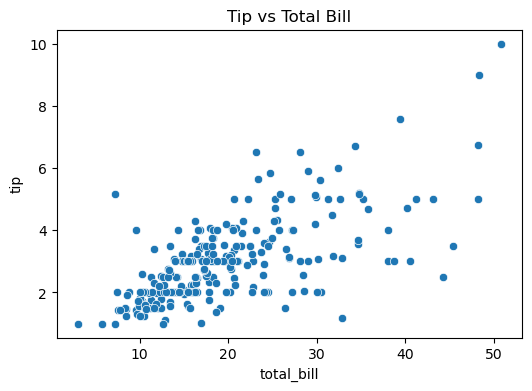

In [13]:
# Q5.1.1: Tip vs Total Bill (scatter plot)
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='total_bill', y='tip')
plt.title("Tip vs Total Bill")
plt.show()

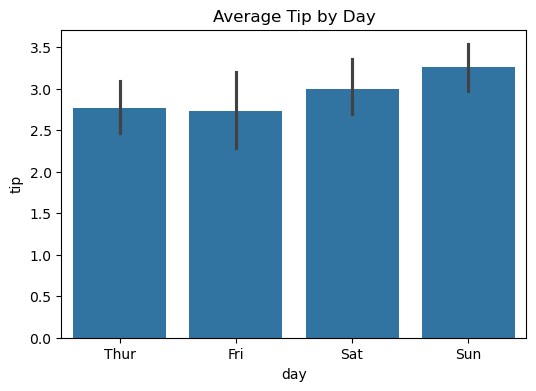

In [14]:
# Q5.1.2: Average Tip by Day (Bar Plot)
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='day', y='tip')
plt.title("Average Tip by Day")
plt.show()

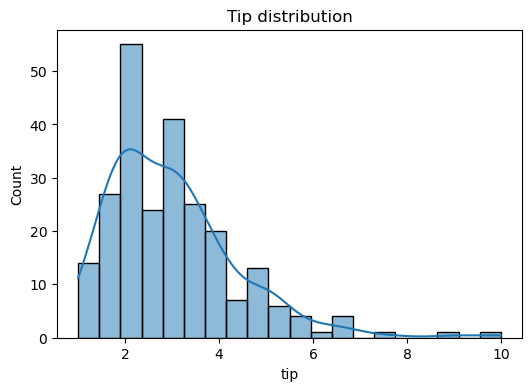

In [15]:
# 5.1.3: Tip distribution (histogram)
plt.figure(figsize=(6,4))
sns.histplot(df['tip'], bins=20, kde=True)
plt.title("Tip distribution")
plt.show()

## Answer Q5.2: Interpret each plot in 1–2 sentences.

The scatter plot shows a strong positive relationship between the total bill and the tip. It's clear from the distribution.

The bar plot suggests slightly higher tips on weekends. (Sundays more, a little less on Saturdays)

The histogram shows that most tips are between 2 and 4 dollars. ALso the most popular values are 2 and 3 dollars.

# Q6: Final Insight & Conclusion (25 marks)

In 6–8 sentences, summarize:
- Who tips more?
- When tips are highest?
- How this insight could help restaurant management.

## Answer Q6:

Customers --
Customers tend to tip more when the total bill is higher. Weekend customers generally spend more and therefore leave larger tips. Larger groups give higher total bills and higher tips in absolute terms.

Restaurant managers -- Managers should schedule more staff on weekends and evenings since bills and tips are higher. Encouraging upselling can increase total bills and therefore increase tips. So it helps optimize staffing and service strategy.

In [21]:
weekday = df.isin(['Thur', 'Fri'])
weekend = df.isin(['Sat', 'Sun'])

weekday.shape()
weekend.shape()

TypeError: 'tuple' object is not callable

In [18]:
df.day.unique()

['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, object): ['Thur', 'Fri', 'Sat', 'Sun']